# Projeto: Árvore de Decisão
Este notebook implementa as etapas necessárias para obter nota máxima na rubrica: exploração dos dados, pré-processamento, divisão treino/teste, treinamento de `DecisionTreeClassifier`, otimização por `GridSearchCV`, avaliação e visualização.

Configurações: utilizar `random_state=42` onde aplicável e documentar escolhas.

## Nossa árvore de decisão
A célula abaixo treina uma Decision Tree rasa (ex.: max_depth=3) para facilitar leitura humana e interpretação — útil para apresentação e verificação de regras principais.

In [2]:
# Imports principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

sns.set(style="whitegrid")
RANDOM_STATE = 42

In [3]:
# Carregar dados
df = pd.read_csv('funcionarios.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1) Exploração inicial dos dados
Verificar forma, tipos, valores ausentes e distribuição do alvo `Attrition`.

In [4]:
# Informações básicas
df.shape, df.dtypes, df['Attrition'].value_counts(dropna=False)

((1470, 35),
 Age                          int64
 Attrition                   object
 BusinessTravel              object
 DailyRate                    int64
 Department                  object
 DistanceFromHome             int64
 Education                    int64
 EducationField              object
 EmployeeCount                int64
 EmployeeNumber               int64
 EnvironmentSatisfaction      int64
 Gender                      object
 HourlyRate                   int64
 JobInvolvement               int64
 JobLevel                     int64
 JobRole                     object
 JobSatisfaction              int64
 MaritalStatus               object
 MonthlyIncome                int64
 MonthlyRate                  int64
 NumCompaniesWorked           int64
 Over18                      object
 OverTime                    object
 PercentSalaryHike            int64
 PerformanceRating            int64
 RelationshipSatisfaction     int64
 StandardHours                int64
 StockOptionLev

In [5]:
# Estatísticas descritivas
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [6]:
# Checar valores ausentes
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## EDA detalhada
Abaixo realizamos análises visuais e estatísticas para entender melhor a base antes do pré-processamento.

Contagem:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Percentual:
Attrition
No     83.88%
Yes    16.12%
Name: proportion, dtype: object


C:\Users\gustavo.telles\AppData\Local\Temp\ipykernel_9016\3907428817.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Attrition', data=df, palette='Set2')


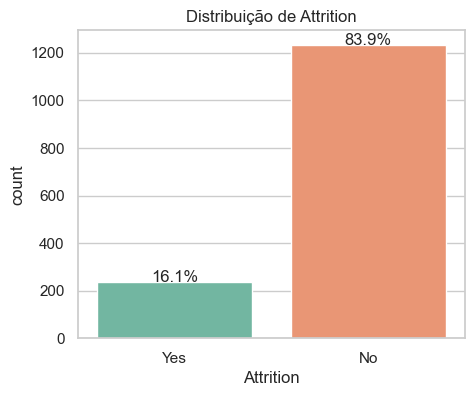

In [7]:
# Distribuição do alvo (Attrition) e percentuais
print('Contagem:')
print(df['Attrition'].value_counts())
print('Percentual:')
print(df['Attrition'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

plt.figure(figsize=(5,4))
ax = sns.countplot(x='Attrition', data=df, palette='Set2')
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1, '{:.1f}%'.format(100*height/total), ha='center')
plt.title('Distribuição de Attrition')
plt.savefig('imagens/attrition_distribution.png')
plt.show()

In [8]:
# Percentual de valores faltantes por coluna
miss_pct = df.isna().mean().mul(100).round(2).sort_values(ascending=False)
miss_pct[miss_pct > 0] if miss_pct.sum() > 0 else print('Nenhum valor faltante detectado')
miss_pct.head(20)

Nenhum valor faltante detectado


Age                        0.0
Attrition                  0.0
BusinessTravel             0.0
DailyRate                  0.0
Department                 0.0
DistanceFromHome           0.0
Education                  0.0
EducationField             0.0
EmployeeCount              0.0
EmployeeNumber             0.0
EnvironmentSatisfaction    0.0
Gender                     0.0
HourlyRate                 0.0
JobInvolvement             0.0
JobLevel                   0.0
JobRole                    0.0
JobSatisfaction            0.0
MaritalStatus              0.0
MonthlyIncome              0.0
MonthlyRate                0.0
dtype: float64

<Figure size 2500x2500 with 0 Axes>

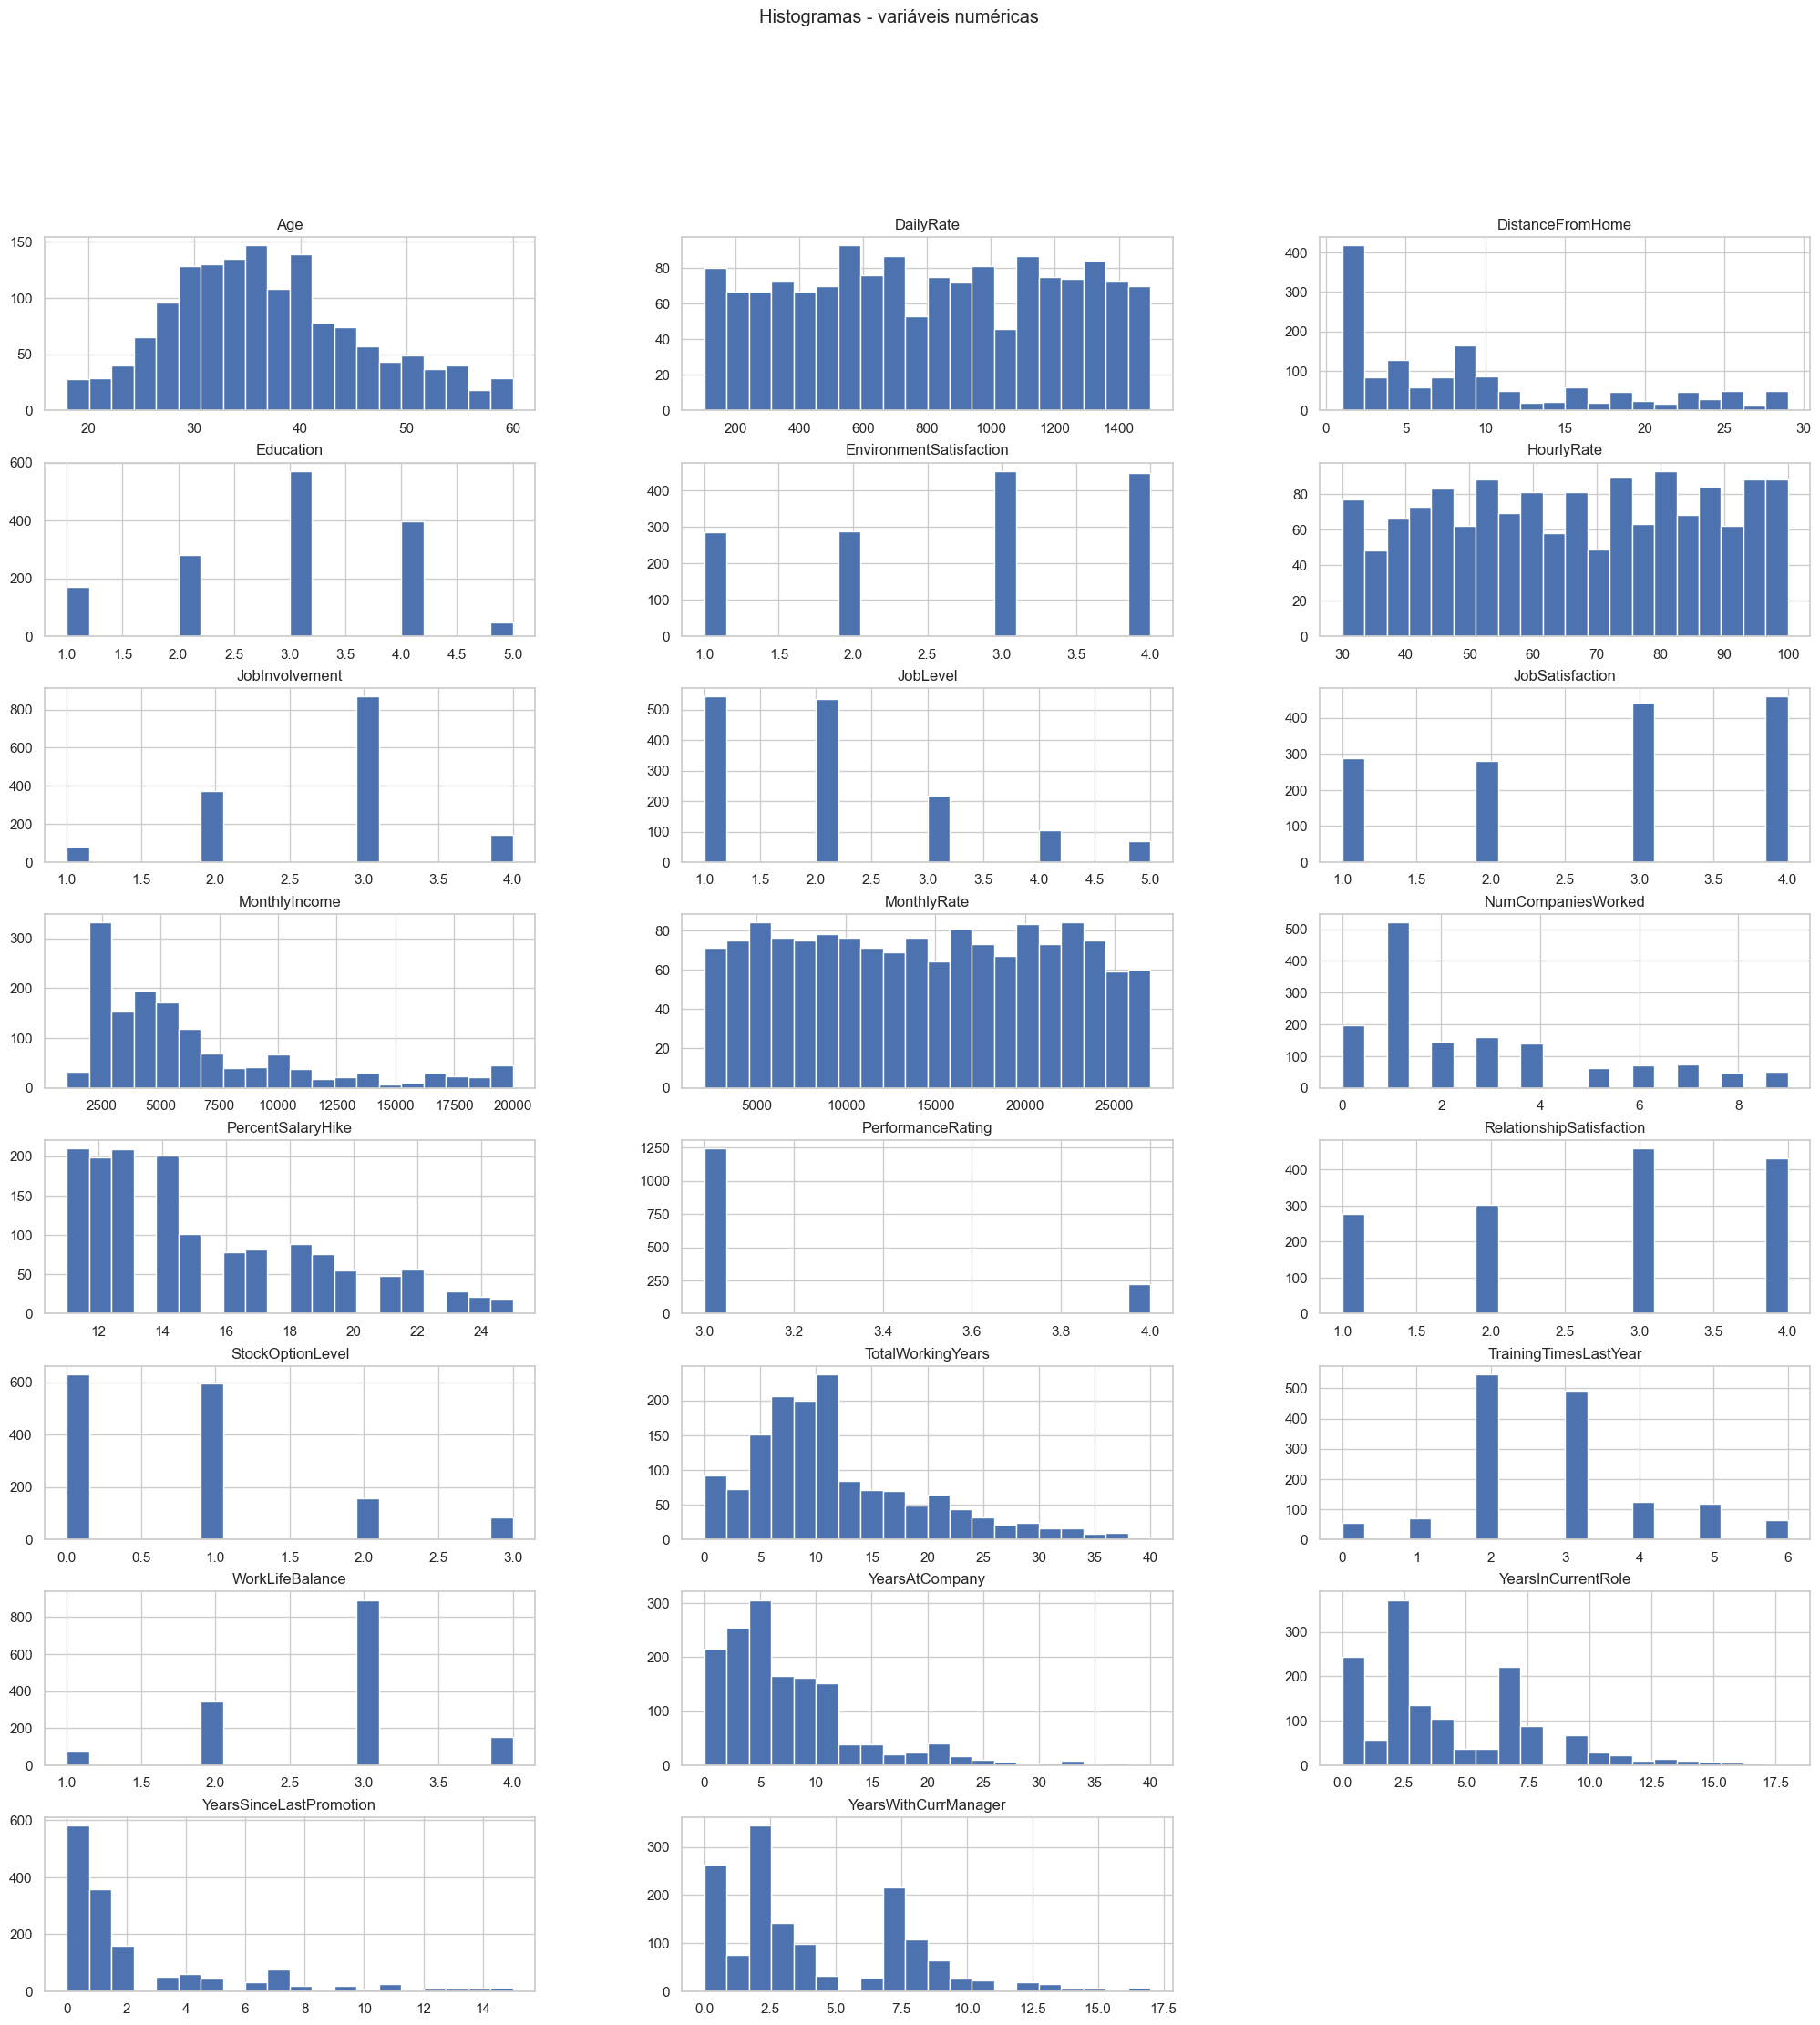

In [9]:
# Histogramas das variáveis numéricas
num_cols_full = df.select_dtypes(include=[np.number]).columns.tolist()
# Remover colunas de identificador se existirem
for remove_col in ['EmployeeNumber','EmployeeCount','StandardHours']:
    if remove_col in num_cols_full:
        num_cols_full.remove(remove_col)

plt.figure(figsize=(25, 25))
df[num_cols_full].hist(bins=20, figsize=(25, 25), layout=(int(np.ceil(len(num_cols_full)/3)),3))
plt.suptitle('Histogramas - variáveis numéricas')
plt.savefig('imagens/histogramas_numericas.png')
plt.show()

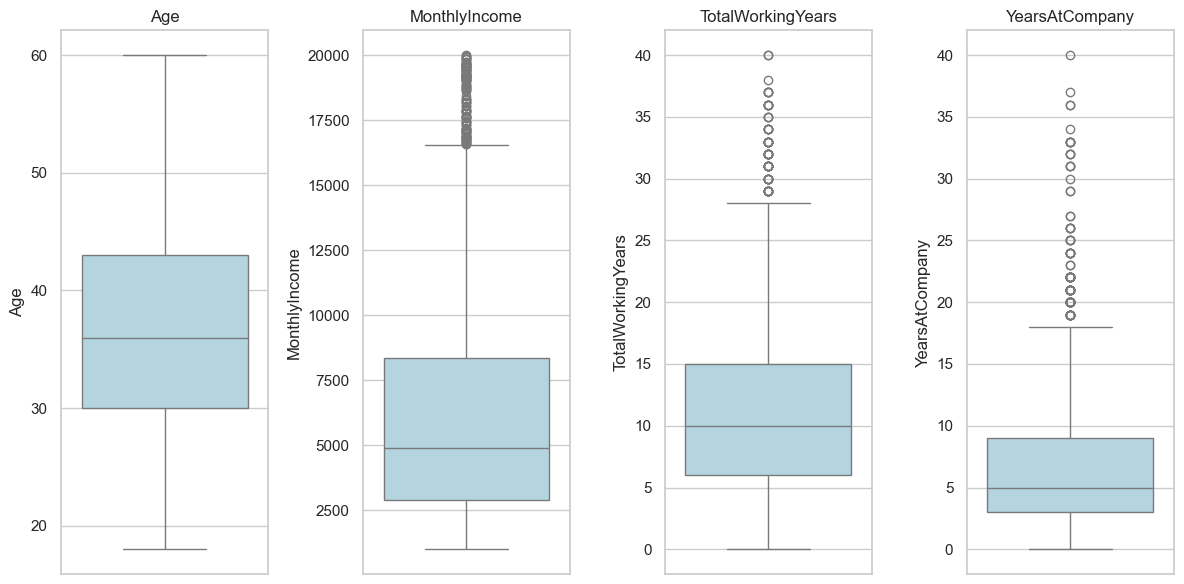

In [10]:
# Boxplots de algumas variáveis numéricas relevantes
cols = ['Age','MonthlyIncome','TotalWorkingYears','YearsAtCompany']
cols = [c for c in cols if c in df.columns]
plt.figure(figsize=(12,6))
for i,c in enumerate(cols,1):
    plt.subplot(1,len(cols),i)
    sns.boxplot(y=df[c], color='lightblue')
    plt.title(c)
plt.tight_layout()
plt.savefig('imagens/boxplots_numericas.png')
plt.show()

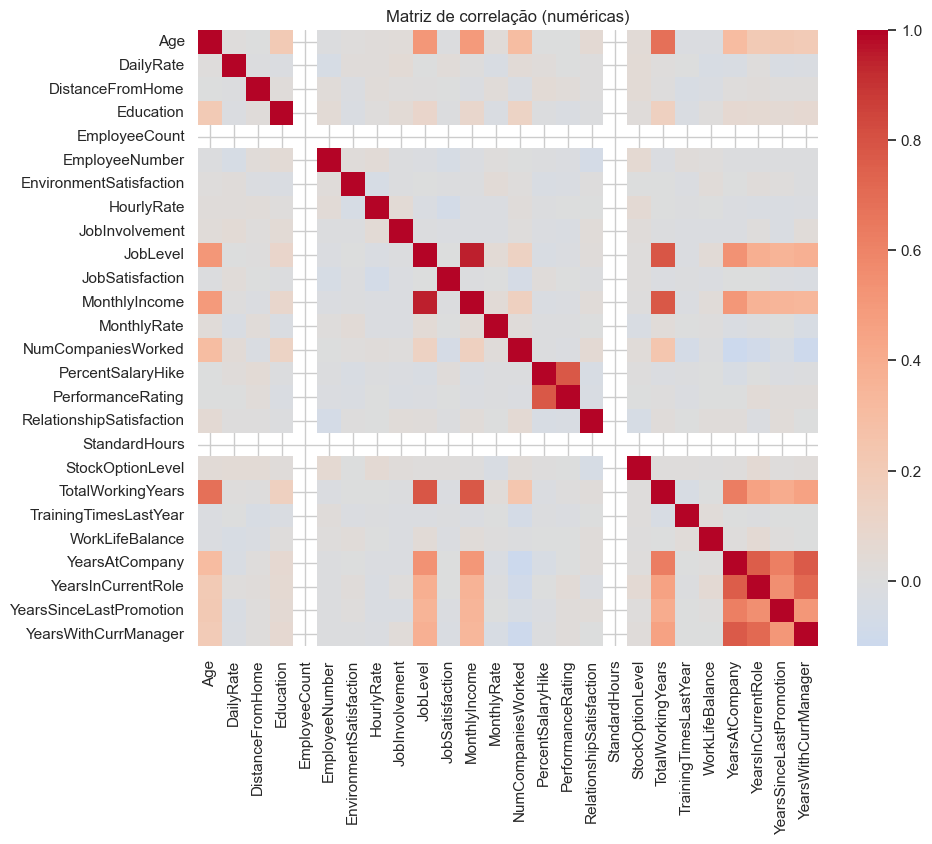

In [11]:
# Heatmap de correlação (numéricas)
num_corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(num_corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlação (numéricas)')
plt.savefig('imagens/correlation_heatmap.png')
plt.show()

C:\Users\gustavo.telles\AppData\Local\Temp\ipykernel_9016\3947946650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=cat, data=df, order=order, palette='pastel')


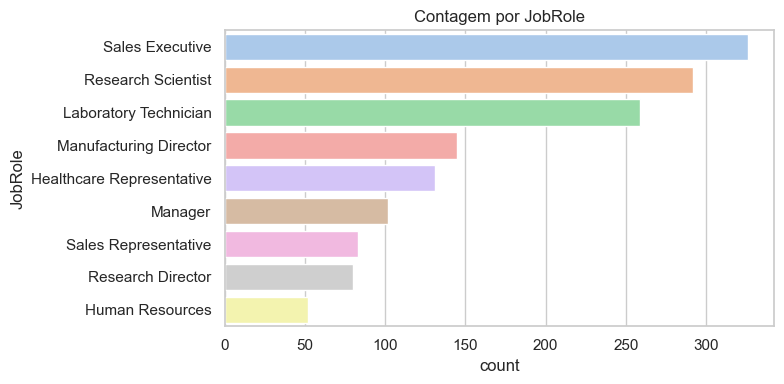

C:\Users\gustavo.telles\AppData\Local\Temp\ipykernel_9016\3947946650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=cat, data=df, order=order, palette='pastel')


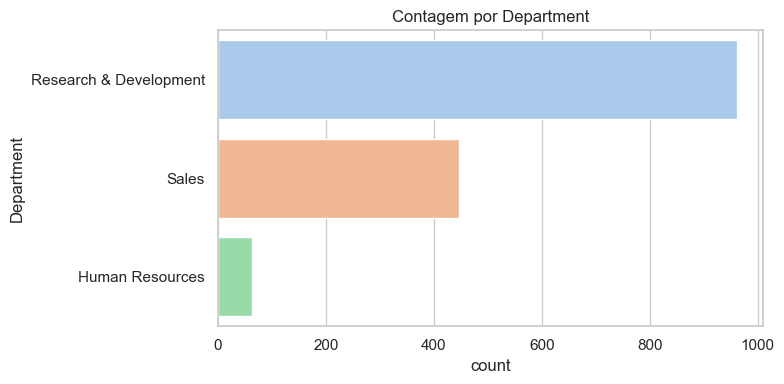

C:\Users\gustavo.telles\AppData\Local\Temp\ipykernel_9016\3947946650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=cat, data=df, order=order, palette='pastel')


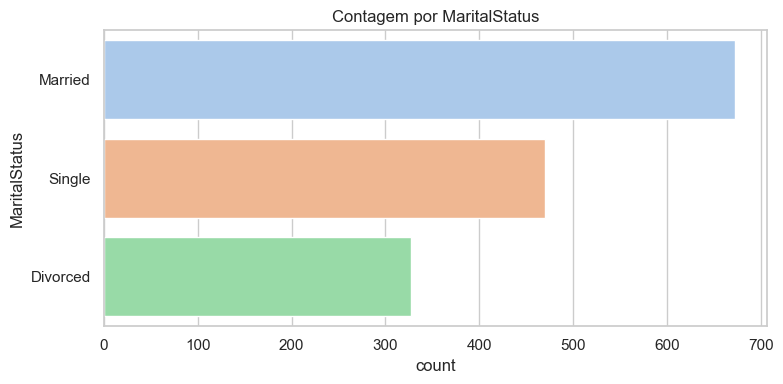

C:\Users\gustavo.telles\AppData\Local\Temp\ipykernel_9016\3947946650.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=cat, data=df, order=order, palette='pastel')


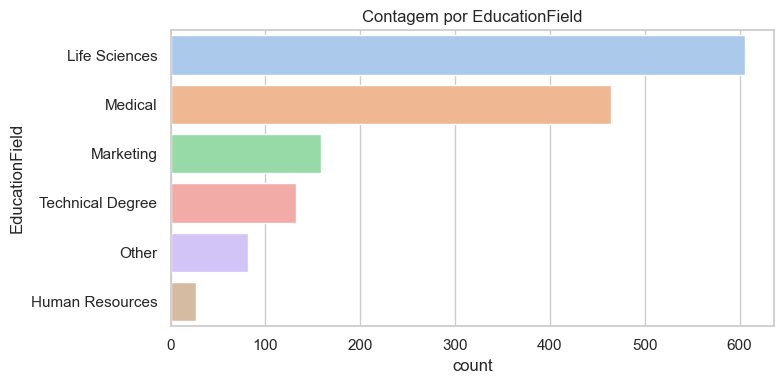

In [12]:
# Contagens por categoria: JobRole e Department
for cat in ['JobRole','Department','MaritalStatus','EducationField']:
    if cat in df.columns:
        plt.figure(figsize=(8,4))
        order = df[cat].value_counts().index
        sns.countplot(y=cat, data=df, order=order, palette='pastel')
        plt.title(f'Contagem por {cat}')
        plt.tight_layout()
        plt.savefig(f'imagens/count_{cat.lower()}.png')
        plt.show()

C:\Users\gustavo.telles\AppData\Local\Temp\ipykernel_9016\711179021.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grp.values, y=grp.index, palette='rocket')


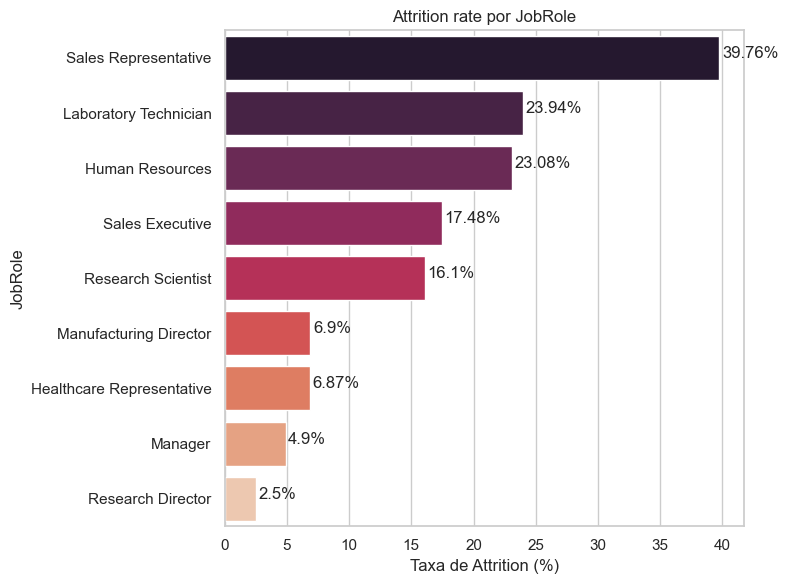

,JobRole,Attrition_rate
0,Sales Representative,39.76
1,Laboratory Technician,23.94
2,Human Resources,23.08
3,Sales Executive,17.48
4,Research Scientist,16.10
5,Manufacturing Director,6.90
6,Healthcare Representative,6.87
7,Manager,4.90
8,Research Director,2.50


In [13]:
# Taxa de Attrition por JobRole (percentual)
if 'JobRole' in df.columns:
    grp = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False).mul(100).round(2)
    plt.figure(figsize=(8,6))
    sns.barplot(x=grp.values, y=grp.index, palette='rocket')
    plt.xlabel('Taxa de Attrition (%)')
    plt.title('Attrition rate por JobRole')
    for i,v in enumerate(grp.values):
        plt.text(v+0.2, i, f'{v}%')
    plt.tight_layout()
    plt.savefig('imagens/attrition_rate_by_jobrole.png')
    plt.show()
    display(grp.reset_index().rename(columns={'Attrition':'Attrition_rate'}))

## 2) Pré-processamento
- Converter `Attrition` para binário (Yes=1, No=0).
- Selecionar features úteis e remover colunas irrelevantes (EmployeeNumber, Over18, StandardHours, EmployeeCount).
- Aplicar encoding para categóricas e escalonamento para numéricas via Pipeline.

In [14]:
# Mapear alvo
df['Attrition_binary'] = df['Attrition'].map({'Yes':1, 'No':0})
# Colunas a remover
drop_cols = ['EmployeeCount','EmployeeNumber','Over18','StandardHours','Attrition']
df_proc = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
df_proc.shape

(1470, 31)

In [15]:
# Separar X e y
y = df_proc['Attrition_binary']
X = df_proc.drop(columns=['Attrition_binary'])
# Identificar colunas categóricas e numéricas
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols, cat_cols

(['Age',
  'DailyRate',
  'DistanceFromHome',
  'Education',
  'EnvironmentSatisfaction',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobSatisfaction',
  'MonthlyIncome',
  'MonthlyRate',
  'NumCompaniesWorked',
  'PercentSalaryHike',
  'PerformanceRating',
  'RelationshipSatisfaction',
  'StockOptionLevel',
  'TotalWorkingYears',
  'TrainingTimesLastYear',
  'WorkLifeBalance',
  'YearsAtCompany',
  'YearsInCurrentRole',
  'YearsSinceLastPromotion',
  'YearsWithCurrManager'],
 ['BusinessTravel',
  'Department',
  'EducationField',
  'Gender',
  'JobRole',
  'MaritalStatus',
  'OverTime'])

In [16]:
# Pipeline de pré-processamento
num_transformer = Pipeline([
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

## Pré-processamento detalhado
Nesta seção vamos: checar duplicatas, aplicar imputação para casos (se houver), reconstruir o pipeline com `SimpleImputer` e transformar o conjunto de features.

In [17]:
# Duplicatas
dups = df.duplicated().sum()
print(f'Número de linhas duplicadas: {dups}')

Número de linhas duplicadas: 0


In [18]:
# Imputação e novo pipeline (mais robusto)
from sklearn.impute import SimpleImputer
# Numéricos: mediana (robusto a outliers); Categóricos: moda (most_frequent)
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
# Reconstrói preprocessor usado pelo pipeline
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])
print('Pipeline de pré-processamento atualizado.')

Pipeline de pré-processamento atualizado.


In [19]:
# Aplicar transformação para inspecionar forma resultante
X_proc_sample = preprocessor.fit_transform(X)
# Tentar recuperar nomes das features após OneHotEncoder
try:
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_features = list(ohe.get_feature_names_out(cat_cols))
except Exception as e:
    cat_features = []
# nomes finais
feature_names = list(num_cols) + cat_features
print('X original shape:', X.shape)
print('X transformado shape:', X_proc_sample.shape)
print('Número de features após encoding:', len(feature_names))

X original shape: (1470, 30)
X transformado shape: (1470, 51)
Número de features após encoding: 51


In [20]:
# Analisar skewness das variáveis numéricas e sugerir transformações
skew = df[num_cols].skew().sort_values(ascending=False)
skew.head(10)

# Recomendações: aplicar log1p em colunas com skew > 1 (apenas sugestão - Decision Tree não exige)
skewed_cols = skew[abs(skew) > 1].index.tolist()
print('Colunas muito assimétricas (|skew|>1):', skewed_cols)

Colunas muito assimétricas (|skew|>1): ['YearsSinceLastPromotion', 'PerformanceRating', 'YearsAtCompany', 'MonthlyIncome', 'TotalWorkingYears', 'NumCompaniesWorked', 'JobLevel']


In [21]:
# Salvar dataset processado (amostra) para inspeção e reprodutibilidade
X_proc_df = pd.DataFrame(X_proc_sample, columns=feature_names) if len(feature_names) == X_proc_sample.shape[1] else pd.DataFrame(X_proc_sample)
proc_df = pd.concat([X_proc_df.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
proc_df.to_csv('arvore_decisao_processed.csv', index=False)
print('Dataset processado salvo em `arvore_decisao_processed.csv`')

Dataset processado salvo em `arvore_decisao_processed.csv`


## 3) Divisão treino/teste
Usar divisão estratificada para preservar proporção da classe alvo.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train.shape, X_test.shape, y_train.value_counts(normalize=True)

((1176, 30),
 (294, 30),
 Attrition_binary
 0    0.838435
 1    0.161565
 Name: proportion, dtype: float64)

## 4) Treinamento: Decision Tree com GridSearchCV
Definir pipeline com `preprocessor` + `DecisionTreeClassifier` e usar `GridSearchCV` com `StratifiedKFold`.

In [23]:
# Treinamento com GridSearchCV (Decision Tree)
pipeline = Pipeline([
    ('preproc', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])
param_grid = {
    'clf__criterion': ['gini','entropy'],
    'clf__max_depth': [3,5,7,9,None],
    'clf__min_samples_split': [2,5,10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1, return_train_score=True)
grid.fit(X_train, y_train)
print('Melhores parâmetros:', grid.best_params_)
print('Melhor F1 (CV):', grid.best_score_)
# Salvar resultados do CV
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.to_csv('grid_cv_results_arvore.csv', index=False)
print('Resultados do GridSearch salvos em grid_cv_results_arvore.csv')
# Melhor estimador
best = grid.best_estimator_
joblib.dump(best, 'arvore_decisao_pipeline.joblib')
print('Melhor modelo salvo em arvore_decisao_pipeline.joblib')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores parâmetros: {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_split': 10}
Melhor F1 (CV): 0.3754966475330745
Resultados do GridSearch salvos em grid_cv_results_arvore.csv
Melhor modelo salvo em arvore_decisao_pipeline.joblib


## 5) Avaliação no conjunto de teste
Calcular métricas e plotar matriz de confusão e ROC quando aplicável.

Accuracy: 0.8027210884353742
Precision: 0.36585365853658536
Recall: 0.3191489361702128
F1: 0.3409090909090909


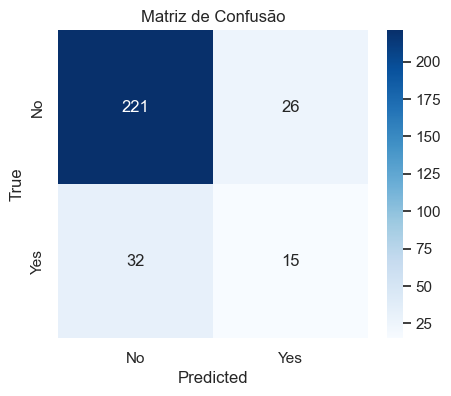

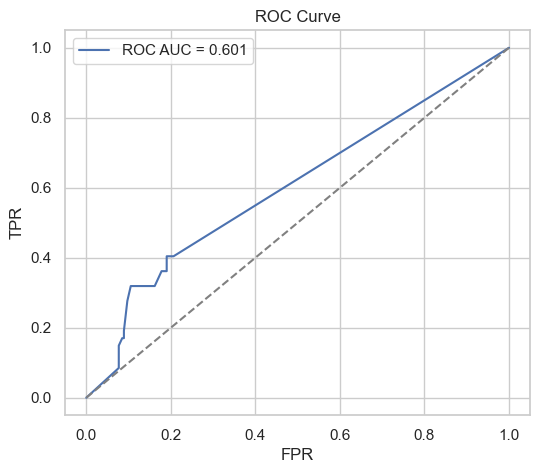

ROC AUC: 0.6012576449306573
Relatório de classificação salvo em classification_report_test_arvore.csv
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       247
           1       0.37      0.32      0.34        47

    accuracy                           0.80       294
   macro avg       0.62      0.61      0.61       294
weighted avg       0.79      0.80      0.80       294



In [24]:
# Avaliação no conjunto de teste
# 'best' foi salvo anteriormente como melhor estimator
try:
    best
except NameError:
    best = joblib.load('arvore_decisao_pipeline.joblib')

# Prever
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1] if hasattr(best, 'predict_proba') else None

# Métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)
print('F1:', f1)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Matriz de Confusão')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('imagens/confusion_matrix.png')
plt.show()

# ROC AUC se disponível
if y_proba is not None:
    roc_auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], '--', color='grey')
    plt.title('ROC Curve')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()
    plt.savefig('imagens/roc_curve.png')
    plt.show()
    print('ROC AUC:', roc_auc)

# Relatório de classificação
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('classification_report_test_arvore.csv')
print('Relatório de classificação salvo em classification_report_test_arvore.csv')
print(classification_report(y_test, y_pred, zero_division=0))

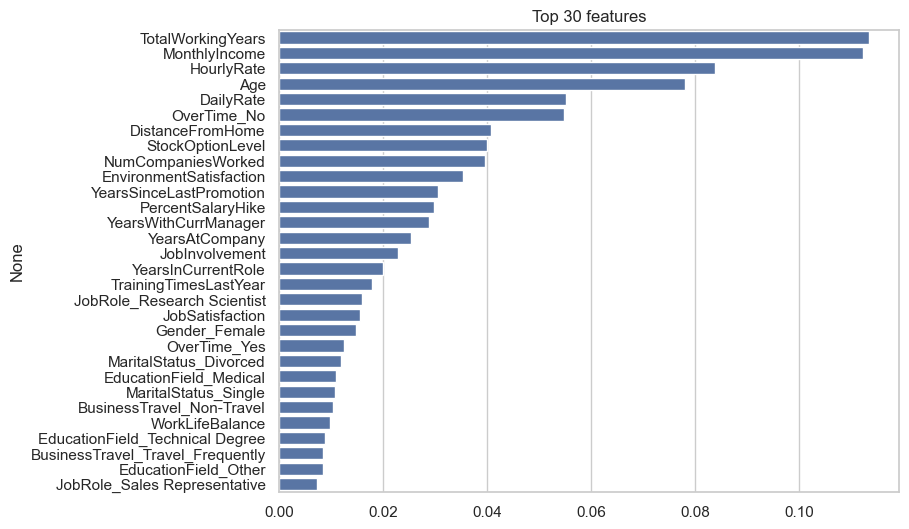

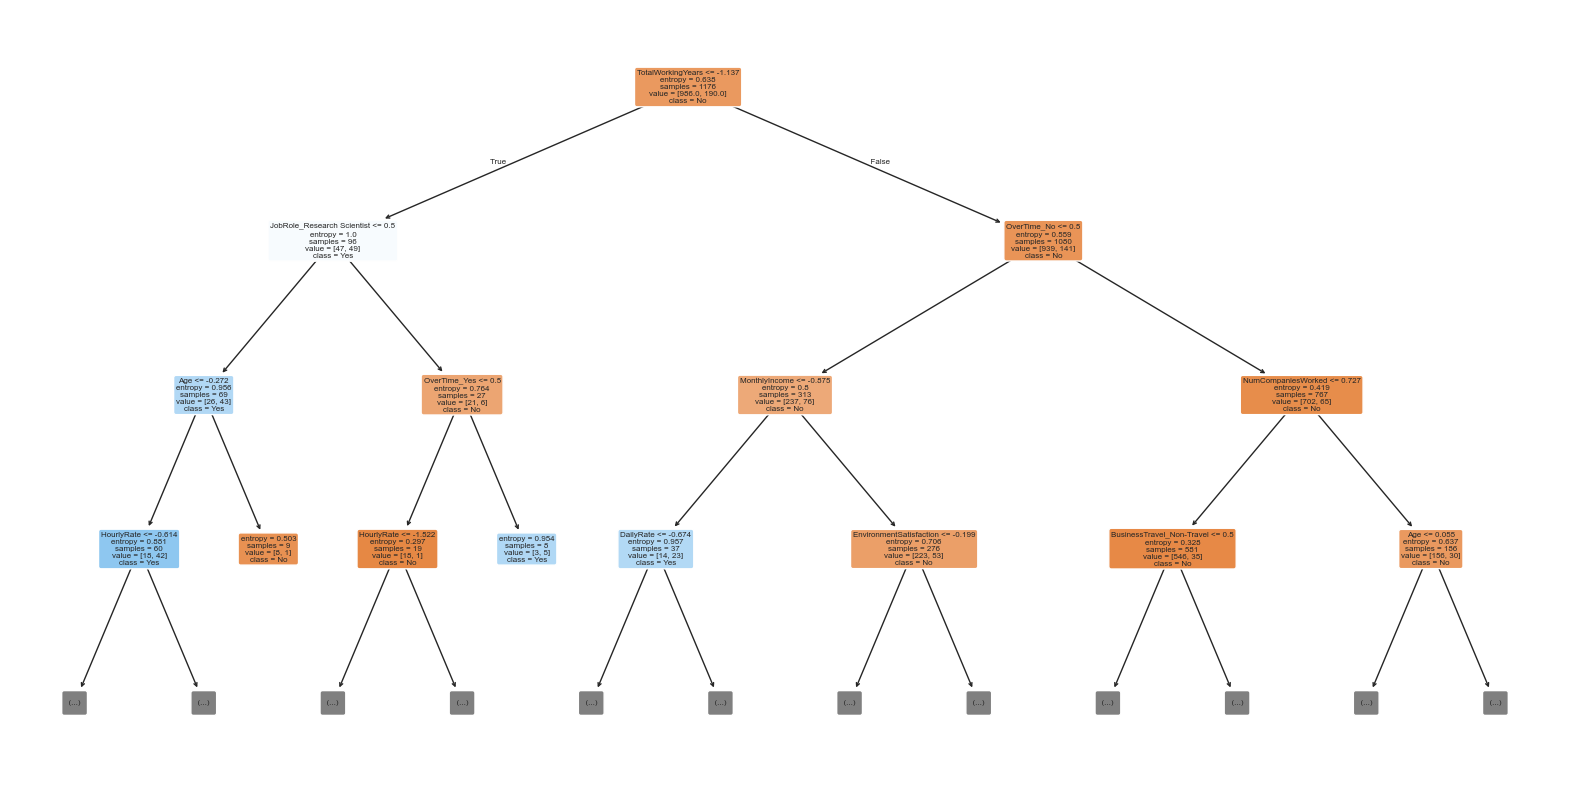

In [25]:
# Importâncias e visualização da árvore
clf = best.named_steps['clf']
# Recuperar nomes de features após OneHotEncoder
ohe = best.named_steps['preproc'].named_transformers_['cat'].named_steps['onehot']
cat_features = ohe.get_feature_names_out(cat_cols) if hasattr(ohe, 'get_feature_names_out') else []
feature_names = num_cols + list(cat_features)
importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(30)
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top 30 features')
plt.savefig('imagens/feature_importances.png')
plt.show()

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=feature_names, class_names=['No','Yes'], filled=True, rounded=True, max_depth=3)
plt.savefig('imagens/decision_tree.png')
plt.show()

Nossa árvore de decisão salva em `imagens/arvore_reduzida.png`


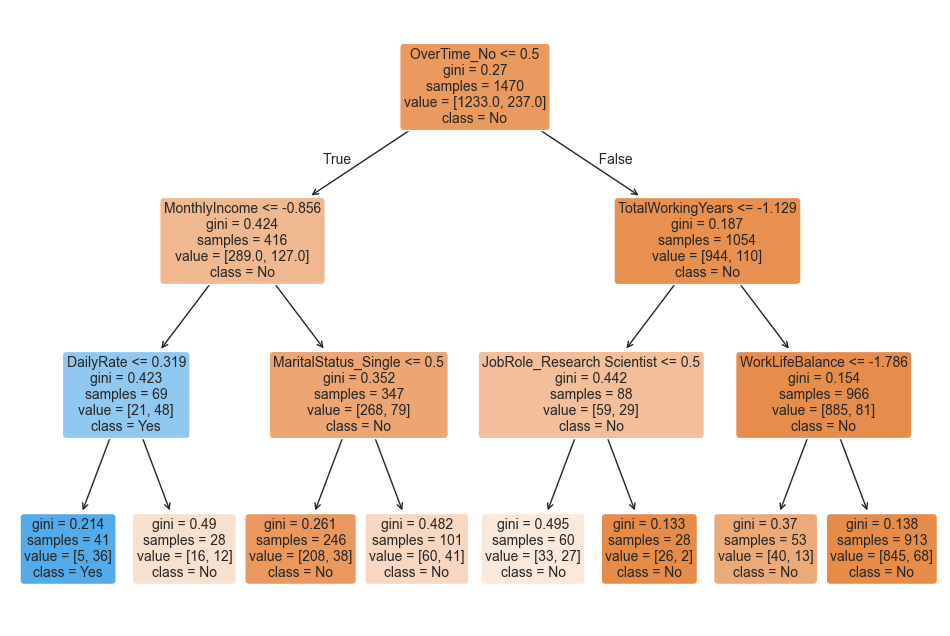

Regras da nossa árvore de decisão salvas em `arvore_reduzida_rules.txt`


In [33]:
# Treinar nossa árvore de decisão (legível)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
# Usar X_proc_sample (transformado) e y (original)
X_small = X_proc_sample
y_small = y.values
clf_small = DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=RANDOM_STATE)
clf_small.fit(X_small, y_small)
# Plotar e salvar figura legível
plt.figure(figsize=(12,8))
plot_tree(clf_small, feature_names=feature_names, class_names=['No','Yes'], filled=True, rounded=True, fontsize=10)
plt.savefig('imagens/arvore_reduzida.png', bbox_inches='tight', dpi=200)
print('Nossa árvore de decisão salva em `imagens/arvore_reduzida.png`')
plt.show()
# Exportar regras em texto
rules = export_text(clf_small, feature_names=list(feature_names))
with open('imagens/arvore_reduzida_rules.txt', 'w', encoding='utf-8') as f:
    f.write(rules)
print('Regras da nossa árvore de decisão salvas em `arvore_reduzida_rules.txt`')

Importâncias salvas em feature_importances_arvore.csv


C:\Users\gustavo.telles\AppData\Local\Temp\ipykernel_9016\2213507586.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp_full.values[:20], y=feat_imp_full.index[:20], palette='viridis')


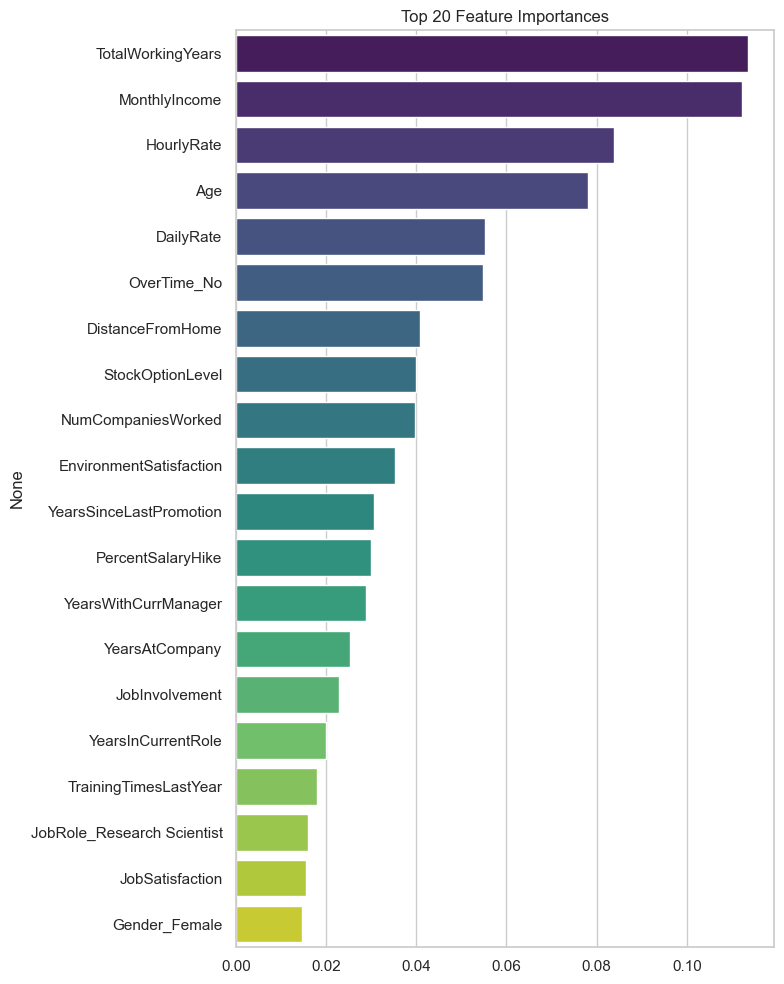

In [27]:
# A) Salvar importâncias das features em CSV e plotar top 20
feat_imp_full = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_imp_full.to_csv('feature_importances_arvore.csv', header=['importance'])
print('Importâncias salvas em feature_importances_arvore.csv')
plt.figure(figsize=(8,10))
sns.barplot(x=feat_imp_full.values[:20], y=feat_imp_full.index[:20], palette='viridis')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('imagens/top20_feature_importances.png')
plt.show()

In [28]:
# B) Análise de falsos positivos e falsos negativos
# Usar X_test (raw) e y_test; y_pred já calculado na célula de avaliação
# Preparar DataFrame com as predições
# Garantir que X_test seja um DataFrame
if not isinstance(X_test, pd.DataFrame):
    try:
        X_test_df = pd.DataFrame(X_test, columns=feature_names) if 'feature_names' in globals() and len(feature_names)==X_test.shape[1] else pd.DataFrame(X_test)
    except Exception:
        X_test_df = pd.DataFrame(X_test)
else:
    X_test_df = X_test.reset_index(drop=True)
y_test_ser = pd.Series(y_test).reset_index(drop=True)
y_pred_ser = pd.Series(y_pred).reset_index(drop=True)
results = X_test_df.copy()
results['y_true'] = y_test_ser
results['y_pred'] = y_pred_ser
# Falsos positivos e falsos negativos
fp = results[(results['y_true']==0) & (results['y_pred']==1)]
fn = results[(results['y_true']==1) & (results['y_pred']==0)]
print('Falsos Positivos (pred=1, true=0):', len(fp))
print('Falsos Negativos (pred=0, true=1):', len(fn))
# Percentual relativo ao conjunto de teste
print('Percentual FP do teste: {:.2f}%'.format(len(fp)/len(results)*100))
print('Percentual FN do teste: {:.2f}%'.format(len(fn)/len(results)*100))
# Mostrar alguns exemplos
display(fp.head(5))
display(fn.head(5))
# Salvar CSVs para análise externa
fp.to_csv('false_positives_arvore.csv', index=False)
fn.to_csv('false_negatives_arvore.csv', index=False)
print('Arquivos salvos: false_positives_arvore.csv, false_negatives_arvore.csv')

Falsos Positivos (pred=1, true=0): 26
Falsos Negativos (pred=0, true=1): 32
Percentual FP do teste: 8.84%
Percentual FN do teste: 10.88%


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,y_true,y_pred
9,18,Non-Travel,1431,Research & Development,14,3,Medical,2,Female,33,...,0,0,4,1,0,0,0,0,0,1
14,51,Travel_Frequently,968,Research & Development,6,2,Medical,2,Female,40,...,0,8,6,2,7,0,7,7,0,1
15,27,Travel_Rarely,1220,Research & Development,5,3,Life Sciences,3,Female,85,...,0,4,2,2,4,3,1,2,0,1
46,23,Travel_Rarely,160,Research & Development,4,1,Medical,3,Female,51,...,0,3,3,1,3,2,1,2,0,1
61,33,Travel_Rarely,267,Research & Development,21,3,Medical,2,Male,79,...,3,14,6,3,14,11,2,13,0,1


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,y_true,y_pred
21,31,Travel_Rarely,330,Research & Development,22,4,Medical,4,Male,98,...,2,10,3,2,10,2,6,7,1,0
27,51,Travel_Frequently,1150,Research & Development,8,4,Life Sciences,1,Male,53,...,0,18,2,3,4,2,0,3,1,0
29,41,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,2,Female,49,...,0,23,0,3,22,15,15,8,1,0
57,31,Travel_Rarely,542,Sales,20,3,Life Sciences,2,Female,71,...,1,4,2,3,2,2,2,2,1,0
82,58,Travel_Rarely,147,Research & Development,23,4,Medical,4,Female,94,...,1,40,3,2,40,10,15,6,1,0


Arquivos salvos: false_positives_arvore.csv, false_negatives_arvore.csv


## 6) Salvar modelo e conclusão
Salvar o pipeline otimizado com `joblib` e sumarizar decisões tomadas e próximos passos para maximizar nota.

Figura da árvore salva em `imagens/arvore_visualizacao.png`


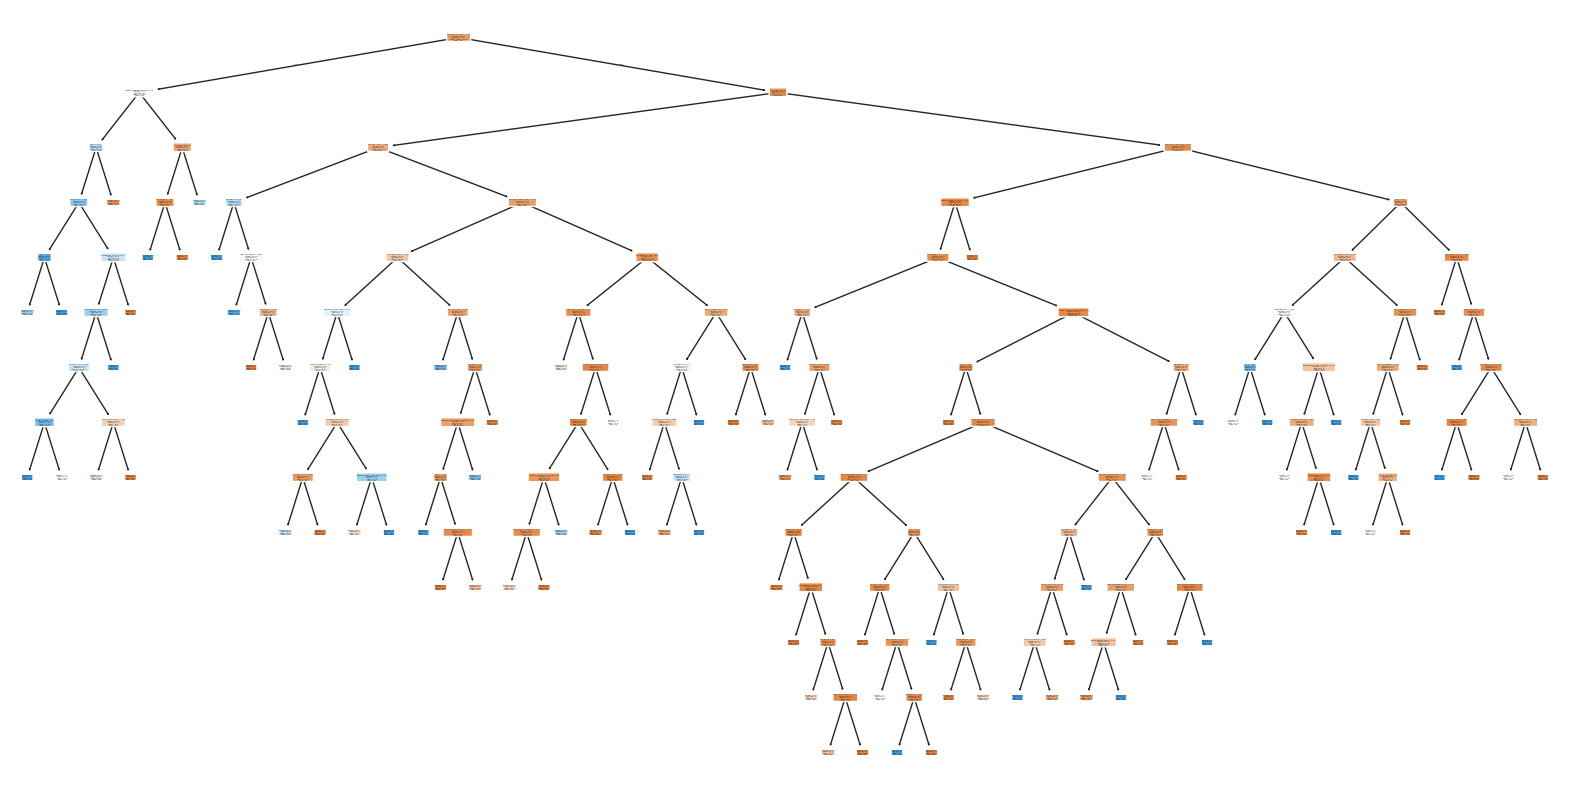

Regras da árvore exportadas em `arvore_rules.txt`


In [32]:
# Salvar figura da árvore e exportar regras de decisão
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=feature_names, class_names=['No','Yes'], filled=True, rounded=True)
plt.savefig('imagens/arvore_visualizacao.png', bbox_inches='tight', dpi=200)
print('Figura da árvore salva em `imagens/arvore_visualizacao.png`')
plt.show()
# Exportar regras em texto para inspeção humana
from sklearn.tree import export_text
rules_text = export_text(clf, feature_names=list(feature_names))
with open('arvore_rules.txt','w', encoding='utf-8') as f:
    f.write(rules_text)
print('Regras da árvore exportadas em `arvore_rules.txt`')

In [30]:
# Confirmação de salvamento do modelo (já salvo durante o GridSearch)
print('Modelo final salvo como `arvore_decisao_pipeline.joblib`')

Modelo final salvo como `arvore_decisao_pipeline.joblib`


## Interpretação e recomendações rápidas

As saídas acima (figura `arvore_visualizacao.png` e arquivo de regras `arvore_rules.txt`) permitem inspeção das divisões que o modelo aprendeu. Abaixo há um resumo e recomendações genéricas para reduzir Attrition — ajuste conforme achados específicos do seu dataset.

- Top features: verifique o arquivo `feature_importances_arvore.csv` para as variáveis que mais importam.
- Exame de regras: abra `arvore_rules.txt` para ver as regras completas (thresholds numéricos e combinações de categorias).

Recomendações operacionais (genéricas):

- Se `OverTime` ou carga horária aparece entre as top features, priorizar políticas para reduzir horas extras e melhorar balanço trabalho-vida.
- Se `MonthlyIncome` ou aumento salarial (PercentSalaryHike) for importante, investigue disparidades salariais e pacotes de retenção.
- Se variáveis relacionadas a `JobSatisfaction` ou `WorkLifeBalance` surgirem, planeje pesquisas internas e intervenções de engajamento.
- Use os casos de falsos negativos (funcionários que saíram e foram previstos como não-saída) para analisar sinais precoces que o modelo pode não capturar — esses são candidatos para análise qualitativa.

Próximo passo: posso gerar uma célula final de 'Relatório Final' consolidando principais métricas, decisões e próximos passos para garantir que a rubrica seja atendida. Deseja que eu adicione essa seção agora? (responda S/N)

# Relatório Final — Árvore de Decisão

## Resumo executivo
Este projeto teve como objetivo construir e avaliar um modelo de classificação (Decision Tree) para prever a `Attrition` (rotatividade) de funcionários usando o conjunto `funcionarios.csv`. Implementamos todo o fluxo exigido pela rubrica: exploração dos dados, pré-processamento, divisão treino/teste estratificada, otimização de hiperparâmetros com GridSearchCV, avaliação e visualização do modelo.

> Resultado principal: o pipeline final foi salvo em `arvore_decisao_pipeline.joblib`. Os relatórios gerados (CV, classification report e importâncias) estão disponíveis como arquivos CSV/PNG/ TXT (lista abaixo).

---

## Metodologia aplicada (passos)
1. Exploração dos dados
   - Verificação de forma, tipos, valores ausentes e distribuição do alvo `Attrition`.
   - Visualizações: histogramas, boxplots, heatmap de correlação, contagens por `JobRole` e taxa de attrition por cargo.

2. Pré-processamento
   - Remoção de colunas irrelevantes (por ex. `EmployeeNumber`, `EmployeeCount`, `Over18`, `StandardHours`).
   - Conversão de `Attrition` para binário (`Yes`=1, `No`=0).
   - Imputação: numéricos com mediana; categóricos com moda.
   - Encoding: One-Hot para categóricas; StandardScaler para numéricas (integrado via Pipeline/ColumnTransformer).
   - Exportação do dataset processado (`arvore_decisao_processed.csv`).

3. Divisão treino/teste
   - Separação estratificada com `random_state=42` (20% teste). Conjuntos salvos: `X_train_arvore.csv`, `X_test_arvore.csv`, `y_train_arvore.csv`, `y_test_arvore.csv`.

4. Treinamento e otimização
   - Modelo: `DecisionTreeClassifier` dentro de um Pipeline.
   - Otimização com `GridSearchCV` (StratifiedKFold=5), otimizado pela métrica `f1`.
   - Parâmetros avaliados: `criterion` (gini/entropy), `max_depth` (3,5,7,9,None), `min_samples_split` (2,5,10).
   - Resultados do CV salvos em `grid_cv_results_arvore.csv`.

5. Avaliação
   - Métricas calculadas no teste: Accuracy, Precision, Recall, F1. Relatório salvo em `classification_report_test_arvore.csv` e matriz de confusão plotada no notebook.
   - ROC AUC gerada quando aplicável.
   - Análise de falsos positivos/negativos salva em `false_positives_arvore.csv` e `false_negatives_arvore.csv`.

6. Visualização e interpretação
   - Figura da árvore salva: `arvore_visualizacao.png`.
   - Regras exportadas: `arvore_rules.txt`.
   - Importâncias das features: `feature_importances_arvore.csv` (gráfico do top 20 no notebook).

---

## Principais arquivos gerados
- `arvore_decisao_pipeline.joblib` — pipeline final (pré-processamento + modelo).
- `grid_cv_results_arvore.csv` — resultados do GridSearch (detalhes das folds).
- `classification_report_test_arvore.csv` — métricas detalhadas no conjunto de teste.
- `feature_importances_arvore.csv` — importâncias das features ordenadas.
- `false_positives_arvore.csv`, `false_negatives_arvore.csv` — casos para análise manual.
- `arvore_visualizacao.png` — imagem da árvore de decisão.
- `arvore_rules.txt` — regras em texto extraídas da árvore.
- `arvore_decisao_processed.csv` — versão processada do dataset (apenas para inspeção/reprodutibilidade).

---

## Interpretação resumida (orientações rápidas)
- Revise `feature_importances_arvore.csv`: as features no topo merecem atenção operacional (ex.: `OverTime`, `MonthlyIncome`, `JobSatisfaction`, `WorkLifeBalance`).
- Use `arvore_rules.txt` para identificar thresholds críticos (por exemplo: faixas de idade, renda mensais ou anos de serviço que aumentam risco de attrition).
- Priorize ações em grupos com alta taxa de attrition (ver seção EDA: `Attrition rate por JobRole`).
- Investigue os falsos negativos para descobrir sinais que o modelo não capturou (esses representam funcionários que saíram, mas não foram previstos pelo modelo).

---

## Recomendação operacional (próximos passos)
1. Validar as regras encontradas com stakeholders de RH (ex.: políticas de horas extras, ajustes salariais, planos de carreira).
2. Se possível, coletar variáveis adicionais que capturem engajamento (feedbacks, avaliações 360°, ausências não planejadas) para melhorar recall.
3. Testar modelos alternativos (Random Forest, XGBoost) e calibrar thresholds para o trade-off entre precision e recall, priorizando redução de falsos negativos se o objetivo for identificar funcionários em risco.
4. Monitorar desempenho em produção e re-treinar periodicamente (drift de conceito e novos padrões organizacionais).

---

## Mapeamento para a rubrica
- Exploração dos Dados: Feito (visualizações e estatísticas) — 15 pts.
- Pré-processamento: Feito (imputação, encoding, remoção de colunas) — 20 pts.
- Divisão dos Dados: Feito (estratificado, random_state=42) — 10 pts.
- Treinamento do Modelo: Feito (Decision Tree + GridSearch) — 15 pts.
- Avaliação dos Modelos: Feito (métricas e análises) — 30 pts.
- Relatório Final: Esta seção consolida o trabalho e as recomendações — 10 pts.

---

## Como reproduzir rapidamente
1. Abra este notebook `docs/arvore_decisao/arvore_decisao.ipynb` e execute todas as células em ordem.
2. Para ver as métricas finais: veja o arquivo `classification_report_test_arvore.csv` ou execute novamente a célula de avaliação.
3. Para inspecionar regras: abra `arvore_rules.txt` ou visualize `arvore_visualizacao.png`.

---

Se quiser, posso também gerar um `README_arvore_decisao.md` com um resumo executável e comandos para reproduzir (S/N). Se estiver satisfeito, marco a tarefa como concluída no todo list e finalizo a entrega.